
![Machine Learning Lab](banner.jpg)

# Laboratorio 6

## Objetivos


1. Aplicar técnicas de clustering no supervisado: Implementar y comparar distintos métodos de clustering, como K-Means, Agglomerative Clustering y DBSCAN, para segmentar clientes de un centro comercial.

2. Explorar y preparar los datos: Realizar un análisis exploratorio de los datos, incluyendo la eliminación de columnas irrelevantes y la normalización de variables, para garantizar un procesamiento adecuado en los algoritmos de clustering.

3. Evaluar y visualizar los resultados: Interpretar los clusters generados mediante visualizaciones y métricas de evaluación como el coeficiente de silueta, identificando patrones en la segmentación de clientes.


### Cargar Librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
import seaborn as sns

In [ ]:
!pip install ydata-profiling

### Carga de datos

En este lab utilizaremos datos de compradores de un centro comercial y por medio de métodos no supervisados podremos encontrar los posibles segmentos de mercados


In [2]:
!mkdir datasets
!curl -L -o datasets/customer-segmentation-tutorial-in-python.zip https://www.kaggle.com/api/v1/datasets/download/vjchoudhary7/customer-segmentation-tutorial-in-python
!unzip datasets/customer-segmentation-tutorial-in-python.zip -d datasets/customer-segmentation-tutorial-in-python
!ls datasets/customer-segmentation-tutorial-in-python

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  1583  100  1583    0     0   1802      0 --:--:-- --:--:-- --:--:--  1802
Archive:  datasets/customer-segmentation-tutorial-in-python.zip
  inflating: datasets/customer-segmentation-tutorial-in-python/Mall_Customers.csv  
Mall_Customers.csv


In [3]:
data = pd.read_csv('datasets/customer-segmentation-tutorial-in-python/Mall_Customers.csv')
data['Gender'] = data['Gender'].map({'Female': 0, 'Male': 1})

### Exploración de datos

Antes de entrenar cualquier modelo primero debemos explorar los datos


In [4]:
from ydata_profiling import ProfileReport
profile = ProfileReport(data, title="YData Profiling Report")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 45491.37it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Como podemos ver tenemos una columna única en nuestro dataset. Para evitar que interfiera con los resultados debemos removerla


In [5]:
data.drop(columns=['CustomerID'], inplace=True)

Adicionalmente, los métodos de clustering que probaremos utilizan las distancias entre puntos. Debemos normalizar todas nuestras variables


In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
normalized_data = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

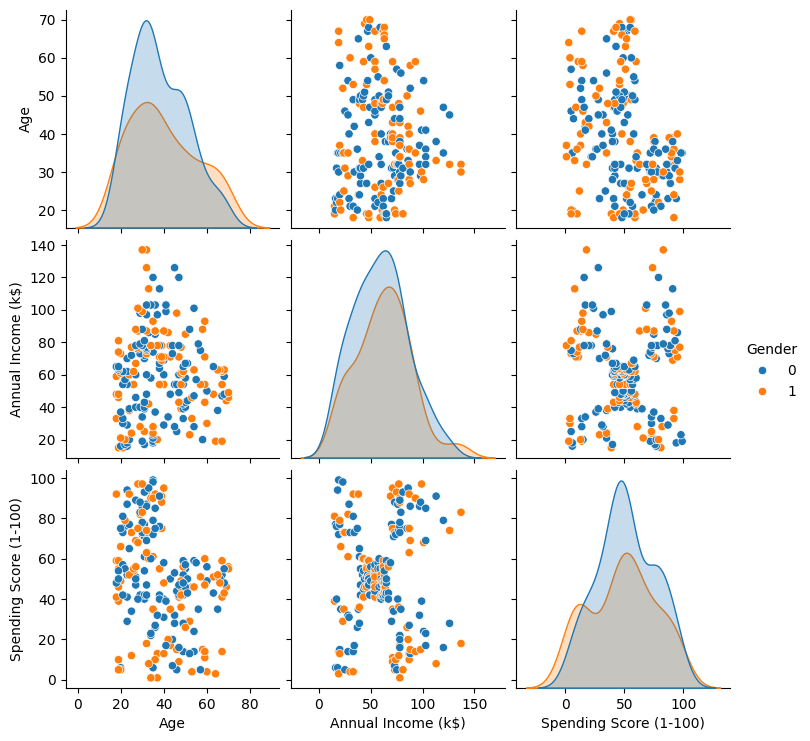

In [10]:
%matplotlib inline

sns.pairplot(data, hue='Gender')
plt.show()

### K-means

K-means usa el promedio de los puntos para determinar los clusters. Esto lo hace por medio de la proximidad o usando la distancia euclidiana.

Adicionalmente podemos usar el elbow-method para determinar cuántos clusters deberíamos crear, esto lo hacemos comparando la inercia de los clusters usando distintos valores para k


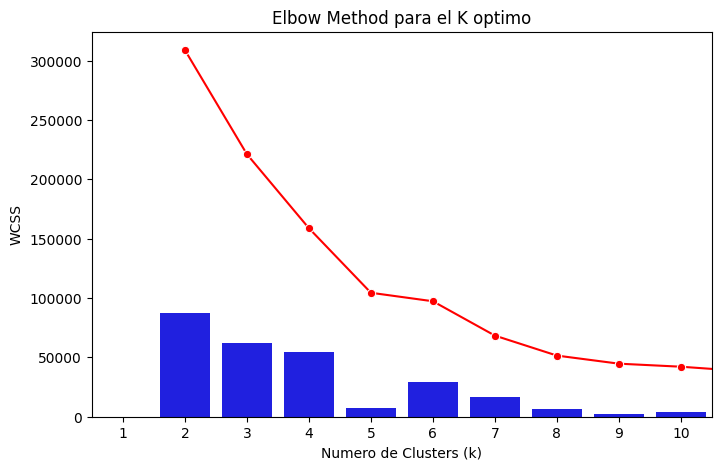

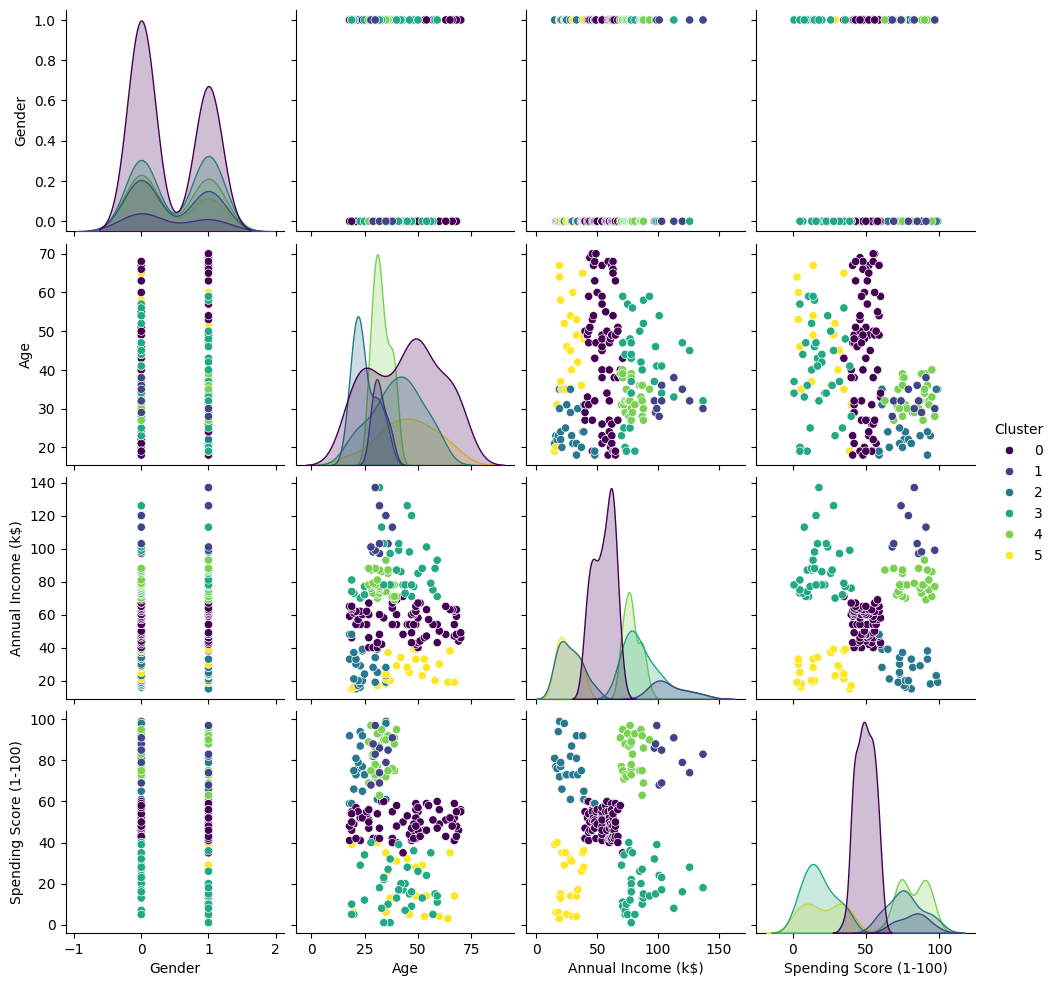

In [11]:
# Aplicar K-means usando Elbow Method para determinar el mejor k
X = data.copy()

# Determinar WCSS para un rango de valores de K
wcss = []
wcss_diff = [0]  # Almacena las diferencias WCSS
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    if k > 1:
        wcss_diff.append(wcss[-2] - wcss[-1])  # Calcula la diferencia WCSS

# Grafica WCSS
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(x=range(1, 11), y=wcss, marker='o', color='red', ax=ax)
sns.barplot(x=range(1, 11), y=wcss_diff, color='blue', ax=ax)
plt.title('Elbow Method para el K optimo')
plt.xlabel('Numero de Clusters (k)')
plt.ylabel('WCSS')
plt.show()

# Aplicar K-means con el K optimo optimal k al observar el grafico
optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Visualizar los clusters
X['Cluster'] = y_kmeans
sns.pairplot(X, hue='Cluster', palette='viridis')
plt.show()

### AgglomerativeClustering

`AgglomerativeClustering` o clustering jerárquico funciona funcionando clusters pequeños en clusters más grandes usando un criterio de reducción de varianza en el caso de usar los valores por defecto de sklearn


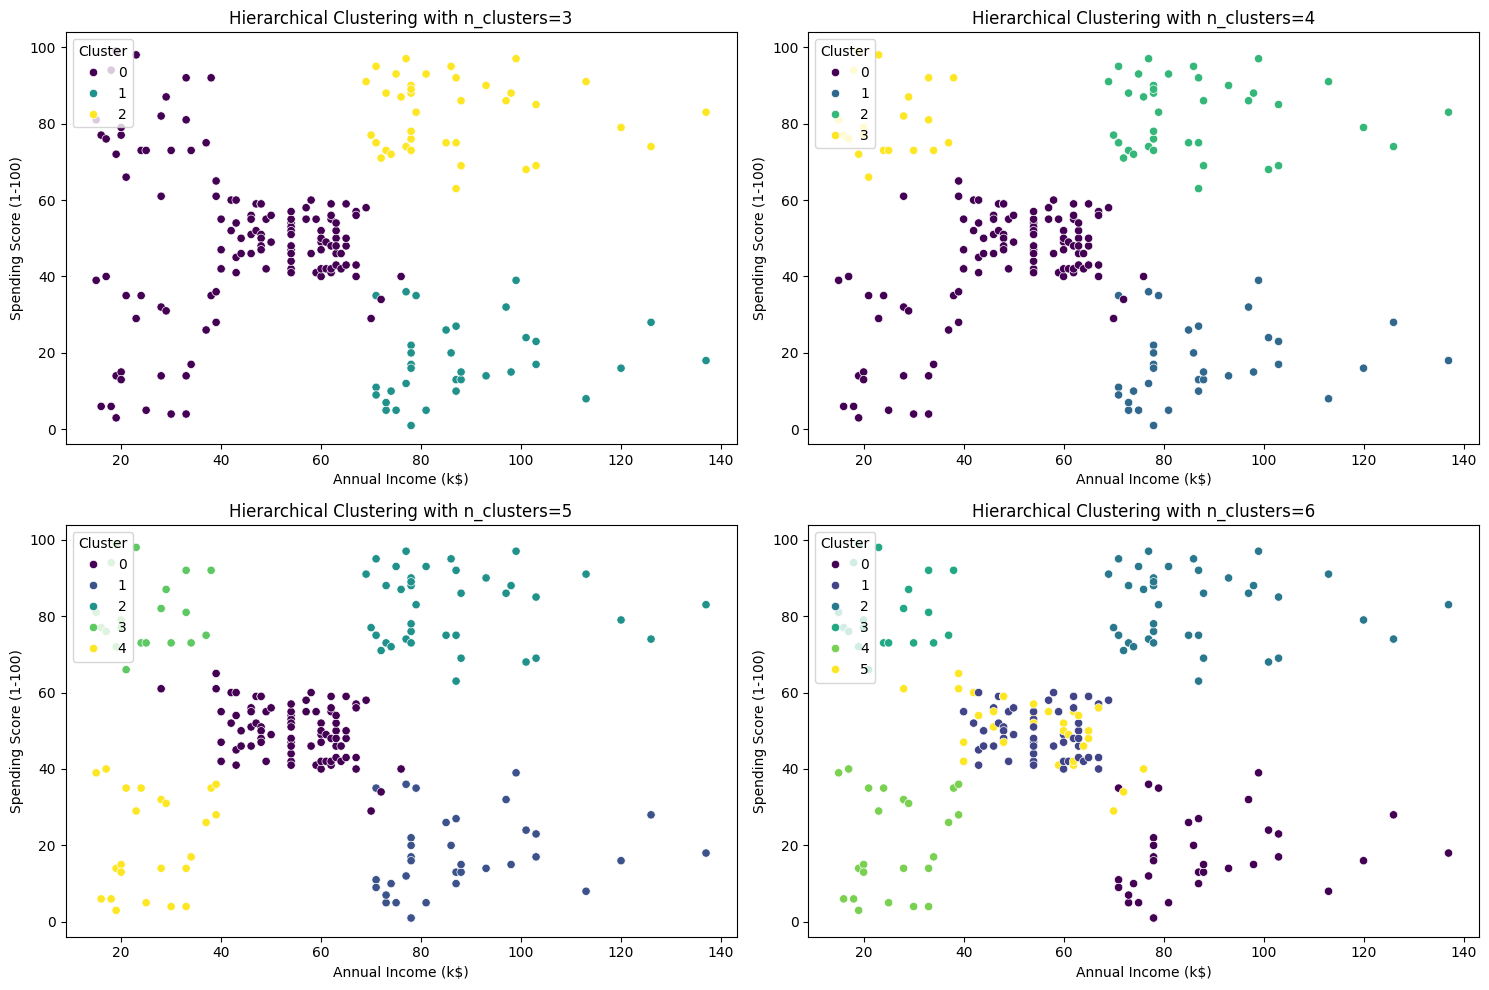

In [12]:
# Fit and predict hierarchical clustering for multiple n_clusters
fig, axes = plt.subplots(2, 2, figsize=(15, 10))  # Create a grid of subplots (2x2) for n_clusters = 3 to 6
axes = axes.flatten()  # Flatten the axes for easier iteration
X = data.copy()

for i, n_clusters in enumerate(range(3, 7)):  # n_clusters in range 3 to 6
    hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
    y_hierarchical = hierarchical.fit_predict(X)

    # Add the cluster labels to the DataFrame
    X[f'Cluster_Hierarchical_{n_clusters}'] = y_hierarchical

    # Plot the clusters
    sns.scatterplot(ax=axes[i], data=X, x='Annual Income (k$)', y='Spending Score (1-100)',
                    hue=f'Cluster_Hierarchical_{n_clusters}', palette='viridis')
    axes[i].set_title(f"Hierarchical Clustering with n_clusters={n_clusters}")
    axes[i].legend(title="Cluster", loc='upper left')

# Adjust layout and show the combined plot
plt.tight_layout()
plt.show()


Una observación importante es cómo se relacionan las clusterizaciones cuando pedimos por números de clusters distintos. Por ejemplo podemos ver que en el caso con `n_clusters=4` los grupos 0 y 3 al unirse forman el grupo 0 en el caso con `n_clusters=3`

### DBSCAN

Sin embargo existe un problema, que sucede si la separación de nuestros datos no es lineal. Tanto k-means como la clusterización jerarquica fallarian. Para solucionar este problema podemos usar dbscan que añade elementos a los clusters según las distancias con sus vecinos.


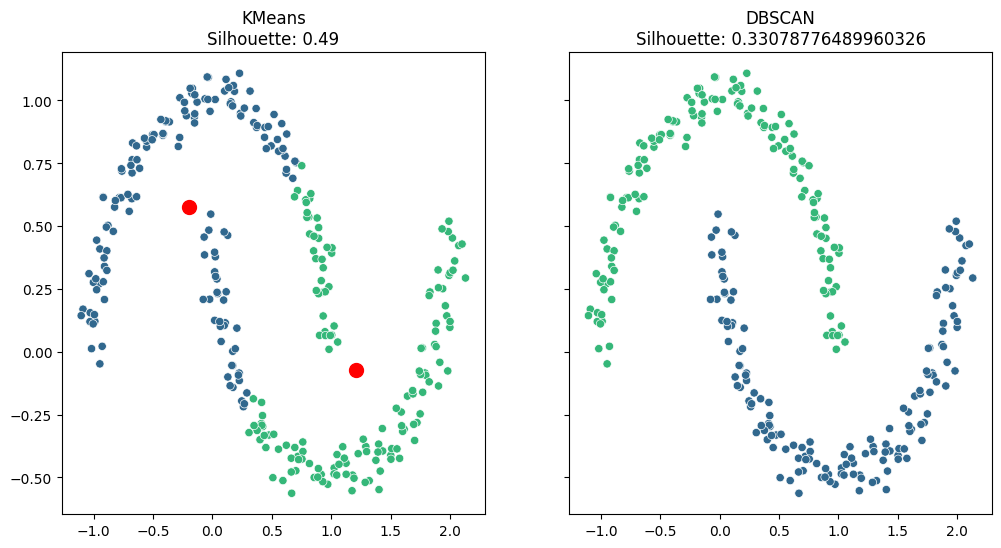

In [13]:
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Generate synthetic non-linear data
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# Apply KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
y_kmeans = kmeans.fit_predict(X)
kmeans_silhouette = silhouette_score(X, y_kmeans)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
y_dbscan = dbscan.fit_predict(X)
dbscan_silhouette = silhouette_score(X, y_dbscan[y_dbscan != -1], metric='euclidean') if len(np.unique(y_dbscan)) > 1 else "N/A"

# Visualize the results
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
sns.scatterplot(ax=axes[0], x=X[:, 0], y=X[:, 1], hue=y_kmeans, palette='viridis', legend=False)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=100, label='Centroids')
axes[0].set_title(f"KMeans\nSilhouette: {kmeans_silhouette:.2f}")
sns.scatterplot(ax=axes[1], x=X[:, 0], y=X[:, 1], hue=y_dbscan, palette='viridis', legend=False)
axes[1].set_title(f"DBSCAN\nSilhouette: {dbscan_silhouette}")
plt.show()

Como podemos ver DBSCAN no tiene problemas a la hora de crear clusters no lineales.

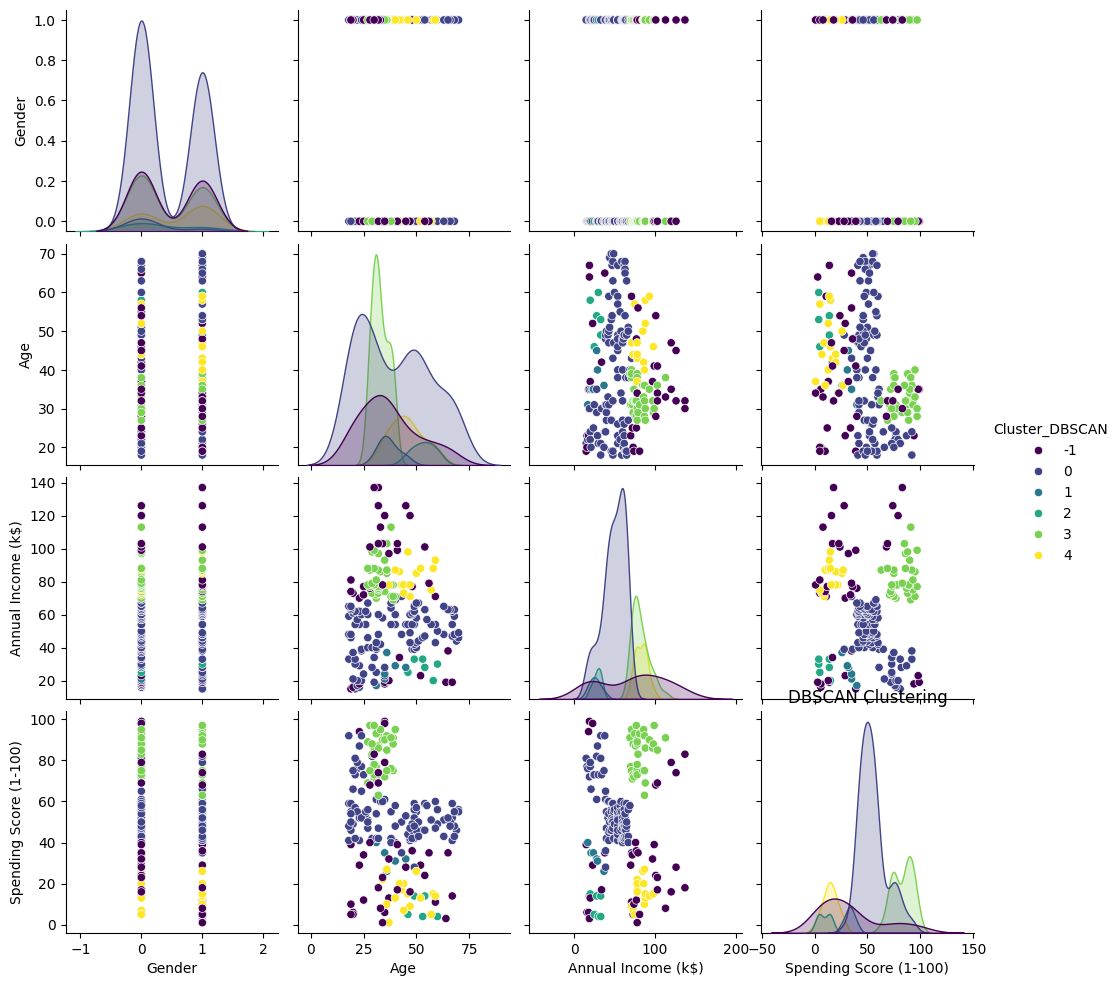

In [14]:
from sklearn.cluster import DBSCAN

X = data.copy()
# Fit and predict using DBSCAN
dbscan = DBSCAN(eps=12, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

# Add the DBSCAN cluster labels to the DataFrame
X['Cluster_DBSCAN'] = y_dbscan

# Plot the results
sns.pairplot(data=X, hue='Cluster_DBSCAN', palette='viridis')
plt.title("DBSCAN Clustering")
plt.show()


Sin embargo, algo importante a tener en cuenta es que DBSCAN no necesariamente incluye todos los puntos del dataset. Algunos de estos puntos el algoritmo los considera ruido. EN este ejemplo esto está expresado como la clase `-1`
